## Imports and Reproducibility Setup

The libraries required for preprocessing and dataset preparation were imported at the beginning of the notebook. A fixed random seed was introduced so that the train-validation split remains reproducible across runs.

In [1]:
import random
import numpy as np
import torch

from pathlib import Path
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset

# A fixed seed is defined so that dataset splitting and other stochastic operations remain reproducible.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# CUDA randomness is also controlled when GPU execution is available.
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Seed set to:", SEED)

Seed set to: 42


## Dataset Root Definition

The retinal OCT dataset root was defined using the confirmed project path. The original training directory will be used to create a reproducible train-validation split, while the official test directory will remain untouched for final evaluation.

In [2]:
from pathlib import Path

# The dataset root is defined using the confirmed project path so that the training and test directories can be accessed consistently.
dataset_root = Path(r"C:\Users\harsh\DL_CW_2\data\raw\OCT2017\OCT2017")

# The original training directory is used for constructing the train-validation split, while the official test directory is preserved for final evaluation.
train_root = dataset_root / "train"
test_root = dataset_root / "test"

# The availability of the required directories is checked before proceeding further.
print("Train path exists:", train_root.exists())
print("Test path exists:", test_root.exists())

Train path exists: True
Test path exists: True


## Final Image Preprocessing and Augmentation

The preprocessing pipeline standardises all retinal OCT scans to a fixed resolution and converts grayscale images into three-channel inputs for compatibility with convolutional models.

Data augmentation was applied conservatively to preserve clinically meaningful structures. Rotation-based transformations were avoided because retinal OCT images exhibit strong horizontal alignment, and such transformations may introduce unrealistic anatomical distortions. Instead, only horizontal flipping and mild spatial translations were used to improve generalisation without compromising structural integrity.

In [21]:
from torchvision import transforms

IMAGE_SIZE = 224

train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    
    # Safe augmentations for OCT
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(
        degrees=0,                 # 🚨 NO rotation
        translate=(0.05, 0.05),    # slight shift only
        fill=0
    ),
    
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Final transforms defined successfully.")

Final transforms defined successfully.


## Full Training Dataset Before Split

The original training directory was first loaded as a complete dataset so that a reproducible train-validation split could be created. This avoids relying on the very small validation folder provided in the dataset version used here.

In [22]:
from torchvision import datasets

# The full original training directory is loaded first so that the train-validation split can be created from a larger sample pool.
full_train_dataset = datasets.ImageFolder(train_root)

# The class labels are obtained from the full training directory to confirm the target categories.
class_names = full_train_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)
print("Total training images before split:", len(full_train_dataset))

Classes: ['CNV', 'DME', 'DRUSEN', 'NORMAL']
Number of classes: 4
Total training images before split: 83484


## Train-Validation Split

A validation set was created by splitting the original training data into training and validation subsets using an 80/20 ratio. This approach ensures that validation performance is measured on a sufficiently large and representative subset of the data.

In [23]:
from torch.utils.data import random_split

# The full training dataset is loaded without transforms to create a controlled split.
full_train_dataset = datasets.ImageFolder(train_root)

# The split ratio is defined.
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

# The split is performed using a fixed random seed for reproducibility.
train_subset, val_subset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print("Train size:", len(train_subset))
print("Validation size:", len(val_subset))

Train size: 66787
Validation size: 16697


## Dataset Objects with Split-Specific Transforms

The original training directory was loaded twice so that different preprocessing pipelines could be assigned to the training and validation subsets. The same split indices were then reused to construct the final transformed subsets.

In [24]:
from torch.utils.data import Subset

# The original training directory is loaded twice so that augmentation can be applied only to the training subset.
train_dataset_full = datasets.ImageFolder(train_root, transform=train_transforms)
val_dataset_full = datasets.ImageFolder(train_root, transform=eval_transforms)

# The split indices produced earlier are reused so that both transformed datasets follow the same partitioning.
train_indices = train_subset.indices
val_indices = val_subset.indices

# The transformed training and validation subsets are reconstructed using the stored split indices.
train_dataset = Subset(train_dataset_full, train_indices)
val_dataset = Subset(val_dataset_full, val_indices)

# The official test directory is loaded separately with evaluation preprocessing only.
test_dataset = datasets.ImageFolder(test_root, transform=eval_transforms)

print("Transformed training subset size:", len(train_dataset))
print("Transformed validation subset size:", len(val_dataset))
print("Test dataset size:", len(test_dataset))

Transformed training subset size: 66787
Transformed validation subset size: 16697
Test dataset size: 968


## Final DataLoader Configuration

The training, validation, and test datasets were wrapped into DataLoader objects to enable efficient mini-batch processing during model training and evaluation. Shuffling was applied to the training set to ensure better generalisation, while validation and test loaders were kept deterministic.

In [29]:
from torch.utils.data import DataLoader

BATCH_SIZE = 64

# The training loader uses shuffling to improve generalisation.
train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

# The validation loader does not shuffle to ensure consistent evaluation.
val_loader = DataLoader(
    val_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# The test loader is also deterministic and used only for final evaluation.
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 1044
Validation batches: 261
Test batches: 16


## Dataloader Preparation

PyTorch dataloaders were constructed for the training, validation, and test subsets. The training loader uses shuffling to improve optimisation, while the validation and test loaders remain deterministic for consistent evaluation.

In [25]:
from torch.utils.data import DataLoader

# A batch size is selected so that the data pipeline remains efficient while fitting comfortably in GPU memory.
BATCH_SIZE = 64

# The training loader is shuffled so that sample order varies across epochs during optimisation.
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

# The validation loader remains deterministic because it is used only for model monitoring.
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

# The test loader is also deterministic so that final evaluation remains stable and reproducible.
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("Train loader batches:", len(train_loader))
print("Validation loader batches:", len(val_loader))
print("Test loader batches:", len(test_loader))

Train loader batches: 1044
Validation loader batches: 261
Test loader batches: 16


## Batch Verification

A sample training batch was retrieved to verify that the preprocessing pipeline produces tensors with the expected dimensions and data type required by the subsequent convolutional models.

In [26]:
# A sample batch is retrieved from the training loader to confirm that the pipeline is producing correctly shaped tensors.
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Batch data type:", images.dtype)
print("Sample labels:", labels[:10])

Image batch shape: torch.Size([64, 3, 224, 224])
Label batch shape: torch.Size([64])
Batch data type: torch.float32
Sample labels: tensor([0, 0, 3, 3, 3, 0, 1, 1, 1, 3])


## Dataset Summary After Split

The final sizes of the training, validation, and test subsets are summarised below. This provides a concise reference for the partitions used during model development and evaluation.

In [27]:
import pandas as pd

# The final dataset sizes are organised into a compact summary table for documentation.
split_summary = pd.DataFrame({
    "Subset": ["Train", "Validation", "Test"],
    "Number of Samples": [len(train_dataset), len(val_dataset), len(test_dataset)]
})

split_summary

,Subset,Number of Samples
0,Train,66787
1,Validation,16697
2,Test,968


## Visual Inspection After Preprocessing

A small subset of transformed training images was visualised to verify that resizing, normalisation, and augmentation were applied correctly. This qualitative inspection ensures that the preprocessing pipeline preserves meaningful retinal structures required for classification.

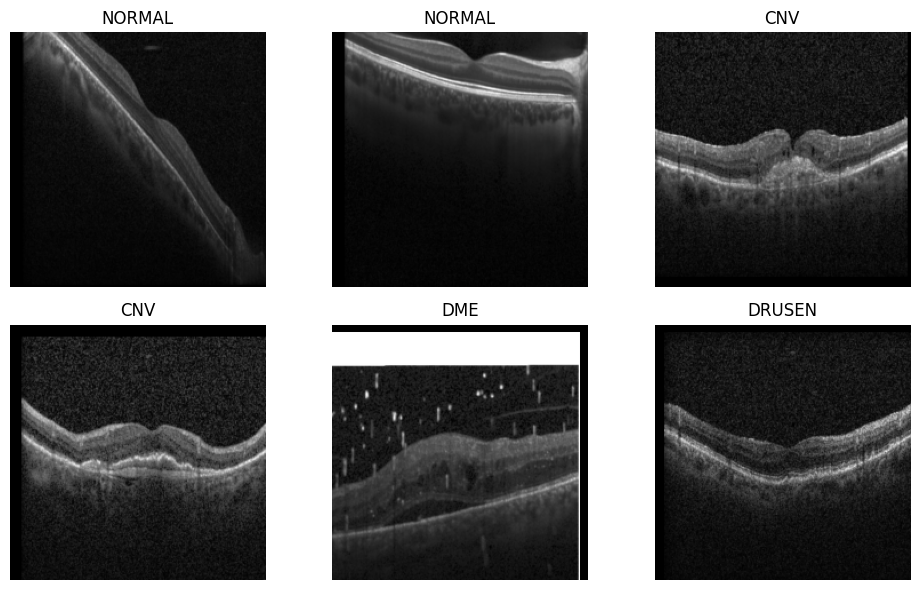

In [28]:
import matplotlib.pyplot as plt
import torch

# A helper function reverses normalisation so that images can be displayed correctly.
def denormalize(image_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return image_tensor * std + mean

# A batch is sampled from the training loader for visual inspection.
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 3, figsize=(10, 6))

for i, ax in enumerate(axes.flat):
    image = denormalize(images[i]).permute(1, 2, 0).clamp(0, 1).numpy()
    ax.imshow(image)
    ax.set_title(class_names[labels[i].item()])
    ax.axis("off")

plt.tight_layout()
plt.show()

## Preprocessing Observations

The preprocessing pipeline successfully prepares the retinal OCT images for model training by standardising image size, converting grayscale scans into a three-channel format, and applying moderate augmentation to the training subset. A reproducible 80:20 split was created from the original training data so that model performance can be monitored on a sufficiently large validation set.

This approach is preferable to relying on the very small validation folder provided in the dataset, as it produces a more reliable basis for model selection and overfitting analysis. The official test set remains untouched and will therefore provide a fair final estimate of generalisation performance.

### Report Note

The dataset was preprocessed by resizing all retinal OCT images to a fixed spatial resolution and converting grayscale scans into three-channel inputs. This allows compatibility with both custom convolutional neural networks and pretrained architectures such as ResNet and EfficientNet.

Instead of relying on the provided validation split, a controlled 80/20 train-validation split was created from the original training data. This ensures a sufficiently large and representative validation set for reliable model selection and performance monitoring, while preserving the integrity of the test set for final evaluation.

“OCT scans exhibit natural variability and noise, which reflects real-world clinical acquisition conditions.”